# Notebook 0 - Digital-twin calibration & Time-Usage-Model (TUM) accounting

**Project:** Real Autonomy in Autonomous Haulage · *Digital-twin experiments*
**Site (anonymised):** *Mine A*, open-pit copper mine, *Region R* · **Operator (anonymised):** *Company X*
**Runtime:** Google Colab (CPU is enough) · **Dependencies:** `numpy`, `pandas`, `matplotlib`, `scipy` (pre-installed in Colab)

> **Central question.** Can a compact, transparent simulator reproduce the *shape* of the autonomous haul cycle and the TUM indicators seen in the operations dashboards, so that later experiments (information latency, heterogeneous communication, human-in-the-loop vs. decentralised control) start from a credible common twin? Notebooks 1–3 re-use exactly the same simulator (`Sim`) defined below.

**Anonymisation.** Company, mine, region and equipment identifiers were replaced (*Company X*, *Mine A*, *Region R*, shovels `SH-1…SH-5`, trucks `AHT-01…AHT-23`). The Time Usage Model codes, the ten cycle phases and the KPI definitions are kept exactly as in the source documents because they are the shared language of the analysis.

## 0. Contents
1. Model description: mining cycle, TUM mapping, assumptions
2. Simulator code (shared by all notebooks)
3. Calibration against the dashboard (and what each agreement is worth)
4. TUM accounting: where does fleet time go?
5. Why dispatch matters: an upper bound under an assumed mechanism
6. Verification checks (time conservation, Little's law)
7. Structural sensitivity: how much do the conclusions depend on the assumed queue mechanism?
8. Limitations and hand-over to Notebooks 1–3
9. References

## 1. Model description

### 1.1 The mining haul cycle (10 phases)
An autonomous haul truck (AHT) repeats a closed loop between a **shovel** (source) and the **crusher** (sink). The ten phases are exactly those shown in the cycle diagram and in the *Autonomous Fleet* dashboard [CYCLE][DASH]:

`Travelling Empty → Queuing at Source → Spotting at Source → Wait for load → Loading → Travelling Full → Queuing at sink → Spotting at sink → Wait for Dump → Dumping → (dispatch decision) → …`

### 1.2 Mapping to the Time Usage Model
The TUM splits calendar time into *required → available → cycle → production* time and assigns standard codes [TUM][GLOS]. The simulator records every truck-minute in exactly one bucket:

| Simulator bucket | TUM code (family) | TUM category |
|---|---|---|
| Travelling empty/full, spotting, loading, dumping | **1010** Autonomous production | Production time (value-adding) |
| Wait for load, wait for dump | **7000** Wait time (wait for dump is assigned here by assumption; the standard's 7020 is the queue at the sink) | Cycle time, *non-value-adding* |
| Queue at source | **7010** | Cycle time, non-value-adding |
| Queue at sink | **7020** | Cycle time, non-value-adding |
| Obstacle / interaction stop | **4070** Wait for access | Unscheduled *process* downtime |
| Emergency A-stop | **4110** Emergency event | Unscheduled process downtime |
| Process delays (hand-over, lock-outs, weather…) | **2xxx / 4xxx** | Scheduled / unscheduled process downtime |
| Refuel | **2020** | Scheduled process downtime |
| Wait for dispatch or approval | **4060 / 4150** (closest standard codes; there is no code for waiting for a dispatch approval) | Unscheduled process downtime |
| Breakdown | **5000** | Unscheduled *equipment* downtime |
| Autonomy hardware event | **5060** | Unscheduled equipment downtime |

Following the TUM note that *"equipment must be available before process downtime can be applied"*, equipment downtime (5xxx) is removed first to obtain **available time**; the standard parameters are then computed as

* **Availability** = available time / required time
* **Utilization** = production time / available time
* **Total utilization** = production time / calendar time
* **Annualised production time** = production time / calendar time × 8 760 h

The dashboard counts wait-for-load and wait-for-dump as *productive* and only the queues as non-productive queue time; both definitions are reported (`utilization` = dashboard definition, `utilization_tum` = strict code 1010) so nothing is hidden.

### 1.3 Simulator design (discrete time, dt = 0.25 min, 12 h shift, 1 h warm-up)
* **Fleet:** 23 AHT, 5 active shovels (`SH-1…SH-5`) and one crusher with 2 dump bays. *Caveat:* the SHOVEL page of the dashboard shows loading time on only four shovels in the reference week, and the total hours on the dashboard suggest ≈ 26 trucks; the five-shovel structure is a modelling choice whose consequences are tested in Section 7.
* **Durations:** log-normal with coefficient of variation 0.25 (0.5 for the short wait phases: wait for load and wait for dump); means from the dashboard (e.g. loading 2.42 min, spotting at source 1.03 min).
* **Geometry:** shovels differ in haul distance (travelling empty 7.0–14.4 min), reproducing the fact that pits/phases have different cycle times [DASH].
* **Reliability:** truck MTBF = 10 h and MTTR = 1.85 h, chosen so that the *simulated availability equals the dashboard's 84.4 %* (MTBF / (MTBF + MTTR)); they sit at the edge of the template thresholds (MTBF > 10 h, MTTR < 2 h [KPI]). There is no scheduled maintenance (TUM 3xxx): all equipment downtime is modelled as breakdown (5000). Shovel MTBF 30 h, MTTR 1.5 h; crusher blockages every ≈ 60 min for ≈ 7 min.
* **Process delays and autonomy events:** probabilistic, so that utilization is in the dashboard range.
* **Baseline dispatch:** a **static plan** (trucks permanently assigned to a shovel: 9-5-4-3-2), i.e. a "legacy" allocation that is imbalanced by construction. It is a *modelling device* that produces the observed queue at source; the imbalance itself is **not** observed in the per-shovel data (Section 7). Notebooks 1 and 3 replace it by dynamic policies.
* **Payload:** 338 t (load factor in the dashboard).

Values that were tuned to the reference dashboard are listed in Section 3.1; values that were assumed (event rates, blockage times, and similar) are plausible engineering assumptions, not measurements. Both kinds are exposed as fields of the `P` dataclass so they can be replaced one at a time with real telemetry (for example, an FMS event export) without touching the simulator's logic.

## 2. Simulator code (identical in Notebooks 0–3)
The cell below defines `P` (parameters), `Sim` (the digital twin), simple dispatch policies and helper functions. Read the docstrings and comments once; later notebooks only *use* it.

In [1]:
import numpy as np, pandas as pd, math
from scipy.stats import t as student_t
try:
    from IPython.display import display
except ImportError:          # plain-python fallback
    display = print
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .25,
                     "axes.spines.top": False, "axes.spines.right": False, "font.size": 9})
from collections import deque
from dataclasses import dataclass, replace

# ---------------------------------------------------------------- state ids
TE, QS, SS, WL, LD, TF, QK, SK, WD, DP, DN, RF, HD, E70, E110, E60, PD = range(17)
PHASES = ["Travelling Empty", "Queuing At Source", "Spotting At Source", "Wait for load", "Loading",
          "Travelling Full", "Queuing at sink", "Spotting at sink", "Wait for Dump", "Dumping"]
SLOT_NAME = PHASES + ["Breakdown (5000)", "Refuel (2020)", "Hold: wait dispatch/approval (4060/4150)",
                      "Obstacle / interaction stop (4070)", "Emergency A-stop (4110)", "Autonomy HW event (5060)", "Process delays (2xxx/4xxx)"]
SLOT_CODE = [1010, 7010, 1010, 7000, 1010, 1010, 7020, 1010, 7000, 1010, 5000, 2020, 4060, 4070, 4110, 5060, 4000]
QUEUE_SLOTS = (QS, QK)              # non value-adding queues (TUM 7010 / 7020)
DOWN_SLOTS = (DN, E60)              # equipment downtime (TUM 5xxx)
CYCLE_SLOTS = list(range(10))

# Reference values read from the (anonymised) operations dashboard, 8-16 Mar window
REF = {"Travelling Empty": 9.90, "Queuing At Source": 6.06, "Spotting At Source": 1.03, "Wait for load": 1.24,
       "Loading": 2.42, "Travelling Full": 9.14, "Queuing at sink": 1.56, "Spotting at sink": 0.70,
       "Wait for Dump": 0.37, "Dumping": 1.09}
REF_KPI = {"cycle_time": 33.51, "availability": 84.39, "utilization": 66.20, "tph_productive": 787.01,
           "hang_time": 2.24, "load_factor_t": 338.0}


@dataclass
class P:
    n_trucks: int = 23
    T: float = 720.0            # one 12 h shift, minutes
    warm: float = 60.0          # warm-up discarded from KPIs
    dt: float = 0.25
    payload: float = 338.0
    # per-shovel geometry (minutes) -> 5 active shovels (a 6th is out of service in the reference data)
    te: tuple = (7.0, 9.1, 10.2, 12.8, 14.4)
    tf: tuple = (6.6, 8.6, 9.6, 11.8, 13.4)
    load: tuple = (2.2, 2.4, 2.4, 2.6, 2.7)
    spot_src: float = 1.03
    wait_load: float = 1.24
    spot_sink: float = 0.70
    wait_dump: float = 0.37
    dump: float = 1.09
    sink_bays: int = 2
    sink_block_mtbf: float = 60.0   # crusher / dump-pocket blockages (min between events)
    sink_block_min: float = 7.0
    static_alloc: tuple = (9, 5, 4, 3, 2)
    cv: float = 0.25
    mtbf_h: float = 10.0
    mttr_h: float = 1.85
    shovel_mtbf_h: float = 30.0
    shovel_mttr_h: float = 1.5
    refuel_min: float = 12.0
    proc_p: float = 0.40        # prob. of a process delay (shift hand-over, lock-outs, weather...) at a decision point
    proc_mean: float = 8.0
    # interaction with heterogeneous traffic (manual / light vehicles / other autonomy stacks)
    lam_int: float = 0.020      # events per travelling minute
    comms_cov: float = 0.5      # 0 = no heterogeneous comms, 1 = full interoperability
    d_soft: float = 0.4
    d_hard: float = 3.5
    p_astop: float = 0.06       # probability that an uncoordinated hard stop escalates to an A-stop
    d_astop: float = 14.0
    lam_hw: float = 0.0015      # autonomy hardware events per travelling minute
    d_hw: float = 6.0
    handshake_gain: float = 0.0  # fraction of spot/wait-for-load time removed by full truck-shovel comms
    shovel_outages: tuple = ()  # ((shovel, start_min, end_min), ...)
    system_outages: tuple = ()  # ((start_min, end_min), ...) central FMS / network outage
    fallback_min: float = 10.0  # after this long in an outage, centralised policies fall back to the static plan
    seed: int = 0


HALF_DT = 0.125   # a timer that is decremented every dt overshoots by dt/2 on average -> compensate


def _ln(rng, mean, cv):
    s2 = math.log(1 + cv * cv)
    return max(0.02, rng.lognormal(math.log(mean) - s2 / 2, math.sqrt(s2)) - HALF_DT)


class Sim:
    def __init__(self, p: P, policy):
        self.p, self.policy = p, policy
        seed_seq = np.random.SeedSequence(p.seed)
        env_seed, policy_seed = seed_seq.spawn(2)
        self.rng = np.random.default_rng(env_seed)
        self.policy_rng = np.random.default_rng(policy_seed)
        N, M = p.n_trucks, len(p.te)
        self.N, self.M = N, M
        self.state = [TE] * N; self.left = [0.0] * N; self.tgt = [0] * N
        self.evt_left = [0.0] * N; self.evt_slot = [E70] * N
        self.hold_left = [0.0] * N; self.pending_tgt = [0] * N
        self.disp_t = [0.0] * N; self.disp_phi = [None] * N
        self.cycle_start = [0.0] * N
        self.fail_t = [self.rng.exponential(p.mtbf_h * 60) for _ in range(N)]
        self.refuel_t = [self.rng.uniform(200, 560) for _ in range(N)]
        self.acct = np.zeros((N, 17))
        self.shq = [[] for _ in range(M)]; self.occ = [-1] * M
        self.committed = [0] * M
        self.down = [False] * M
        self.sh_next_fail = [self.rng.exponential(p.shovel_mtbf_h * 60) for _ in range(M)]
        self.sh_up_at = [0.0] * M
        self.idle = np.zeros(M); self.loads = np.zeros(M); self.qtime = np.zeros(M)
        self.skq = []; self.sink_occ = 0
        self.sink_next_block = self.rng.exponential(p.sink_block_mtbf); self.sink_blocked_until = 0.0
        self.dump_times = []
        self.trips = 0; self.cycles = []; self.n_evt = {E70: 0, E110: 0, E60: 0}
        self.n_touch = 0; self.hist = []; self.dlog = deque()
        self.t = 0.0; self.k = 0
        self.home = []
        for a, n in enumerate(p.static_alloc):
            self.home += [a] * n
        self.home = (self.home + [0] * N)[:N]
        self.qdown_since = [None] * N
        self.tons_log = []
        for i in range(N):
            a = self._pick(i)
            self._depart(i, a, frac=self.rng.uniform(0.2, 1.0))

    # ------------------------------------------------------------ observation API used by policies
    def obs(self, lag):
        if lag <= 0 or not self.hist:
            return list(self.committed), list(self.down)
        idx = max(0, len(self.hist) - 1 - int(round(lag / self.p.dt)))
        return self.hist[idx]

    def recent(self, lag):
        c = [0] * self.M
        for (t, a) in self.dlog:
            if t > self.t - lag:
                c[a] += 1
        return c

    def in_outage(self):
        for (a, b) in self.p.system_outages:
            if a <= self.t < b:
                return a
        return None

    def phys_queue(self):
        return [len(q) + (1 if self.occ[a] >= 0 else 0) for a, q in enumerate(self.shq)]

    # ------------------------------------------------------------ helpers
    def _pick(self, i, redirect=False):
        a = self.policy.choose(self, i, redirect)
        self.disp_phi[i] = getattr(self.policy, "last_phi", None)
        return a

    def _depart(self, i, a, frac=1.0):
        p = self.p
        self.tgt[i] = a; self.committed[a] += 1; self.disp_t[i] = self.t
        self.dlog.append((self.t, a))
        while self.dlog and self.dlog[0][0] < self.t - 30:
            self.dlog.popleft()
        self.state[i] = TE
        self.left[i] = _ln(self.rng, p.te[a], p.cv) * frac

    def _next(self, i):
        """decision point after dumping / repair / refuel"""
        p = self.p
        if self.t >= self.fail_t[i]:
            self.state[i] = DN
            self.left[i] = _ln(self.rng, p.mttr_h * 60, 0.5)
            self.fail_t[i] = self.t + self.left[i] + self.rng.exponential(p.mtbf_h * 60)
            return
        if self.t >= self.refuel_t[i]:
            self.state[i] = RF; self.left[i] = _ln(self.rng, p.refuel_min, 0.2)
            self.refuel_t[i] = 1e9
            return
        if self.rng.random() < p.proc_p:
            self.state[i] = PD; self.left[i] = _ln(self.rng, p.proc_mean, 0.6)
            return
        self._dispatch(i)

    def _dispatch(self, i):
        p = self.p
        pol = self.policy
        if getattr(pol, "central", False):
            o = self.in_outage()
            if o is not None:
                if self.t - o < p.fallback_min:
                    self.state[i] = HD; self.left[i] = p.dt
                    self.pending_tgt[i] = -1
                    return
                a = self.home[i]
                self._depart(i, a); self.disp_phi[i] = None
                return
        a = self._pick(i)
        d = getattr(pol, "delay", lambda s, i: 0.0)(self, i)
        if d > 0:
            self.pending_tgt[i] = a; self.state[i] = HD; self.left[i] = d
            self.committed[a] += 1  # commitment visible immediately
            return
        self._depart(i, a)

    def _spawn_event(self, i):
        p, r = self.p, self.rng
        cov = p.comms_cov
        if r.random() < p.lam_int * p.dt:
            self.evt_slot[i] = E70
            if r.random() < cov:
                self.evt_left[i] = r.exponential(p.d_soft)
            else:
                self.evt_left[i] = r.exponential(p.d_hard)
                if r.random() < p.p_astop:
                    self.evt_slot[i] = E110
                    self.evt_left[i] = _ln(r, self.policy.astop_delay(self) if hasattr(self.policy, "astop_delay") else p.d_astop, 0.4)
                    self.n_evt[E110] += 1
                    self.n_touch += getattr(self.policy, "astop_touch", 1)
            self.n_evt[E70] += 1
        elif r.random() < p.lam_hw * p.dt:
            self.evt_slot[i] = E60; self.evt_left[i] = _ln(r, p.d_hw, 0.4); self.n_evt[E60] += 1

    # ------------------------------------------------------------ main loop
    def _truck(self, i):
        p, dt = self.p, self.p.dt
        if self.evt_left[i] > 0:
            self.acct[i][self.evt_slot[i]] += dt; self.evt_left[i] -= dt
            return
        st = self.state[i]
        self.acct[i][st] += dt
        if st in (TE, TF):
            self._spawn_event(i)
        if st == QS:
            a = self.tgt[i]
            if self.down[a]:
                if self.qdown_since[i] is None:
                    self.qdown_since[i] = self.t
                if self.t - self.qdown_since[i] >= self.policy.redirect_delay and not (
                        getattr(self.policy, "central", False) and self.in_outage() is not None):
                    self.shq[a].remove(i); self.committed[a] -= 1; self.qdown_since[i] = None
                    b = self._pick(i, redirect=True)
                    self._depart(i, b, frac=0.6)
            else:
                self.qdown_since[i] = None
            return
        if st == QK:
            return
        if st == HD:
            self.left[i] -= dt
            if self.pending_tgt[i] == -1:      # waiting out a system outage
                if self.in_outage() is None or self.t - self.in_outage() >= p.fallback_min:
                    self._dispatch(i)
                return
            if self.left[i] <= 0:
                a = self.pending_tgt[i]; self.committed[a] -= 1
                self._depart(i, a)
            return
        self.left[i] -= dt
        if self.left[i] > 0:
            return
        a = self.tgt[i]
        if st == TE:
            self.state[i] = QS; self.shq[a].append(i)
        elif st == SS:
            self.state[i] = WL; self.left[i] = _ln(self.rng, p.wait_load * (1 - 0.7 * p.handshake_gain), p.cv * 2)
        elif st == WL:
            self.state[i] = LD; self.left[i] = _ln(self.rng, p.load[a], p.cv)
        elif st == LD:
            self.state[i] = TF; self.left[i] = _ln(self.rng, p.tf[a], p.cv)
            self.occ[a] = -1; self.committed[a] -= 1; self.loads[a] += 1
            if hasattr(self.policy, "on_loaded"):
                self.policy.on_loaded(self, i, a, self.t - self.disp_t[i])
        elif st == TF:
            self.state[i] = QK; self.skq.append(i)
        elif st == SK:
            self.state[i] = WD; self.left[i] = _ln(self.rng, p.wait_dump, p.cv * 2)
        elif st == WD:
            self.state[i] = DP; self.left[i] = _ln(self.rng, p.dump, p.cv)
        elif st == DP:
            self.sink_occ -= 1
            if self.t >= p.warm:
                self.trips += 1; self.cycles.append(self.t - self.cycle_start[i]); self.dump_times.append(self.t)
            self.cycle_start[i] = self.t
            self._next(i)
        elif st in (DN, RF):
            self._next(i)
        elif st == PD:
            self._dispatch(i)

    def _shovels(self):
        p = self.p
        for a in range(self.M):
            # scripted + random outages (start only when shovel is free)
            forced = any(s == a and b <= self.t < c for (s, b, c) in p.shovel_outages)
            if self.down[a]:
                if not forced and self.t >= self.sh_up_at[a]:
                    self.down[a] = False
                    self.sh_next_fail[a] = self.t + self.rng.exponential(p.shovel_mtbf_h * 60)
            elif self.occ[a] == -1 and (forced or self.t >= self.sh_next_fail[a]):
                self.down[a] = True
                self.sh_up_at[a] = self.t + (0 if forced else _ln(self.rng, p.shovel_mttr_h * 60, 0.5))
            if not self.down[a] and self.occ[a] == -1 and self.shq[a]:
                i = self.shq[a].pop(0)
                self.occ[a] = i; self.state[i] = SS
                self.left[i] = _ln(self.rng, p.spot_src * (1 - 0.7 * p.handshake_gain), p.cv)
            if self.t >= p.warm:
                self.qtime[a] += p.dt * len(self.shq[a])
            if not self.down[a] and self.occ[a] == -1 and not self.shq[a] and self.t >= p.warm:
                self.idle[a] += p.dt

    def _sink(self):
        p = self.p
        if self.t >= self.sink_next_block:
            self.sink_blocked_until = self.t + _ln(self.rng, p.sink_block_min, 0.5)
            self.sink_next_block = self.sink_blocked_until + self.rng.exponential(p.sink_block_mtbf)
        if self.t < self.sink_blocked_until:
            return
        while self.sink_occ < p.sink_bays and self.skq:
            i = self.skq.pop(0); self.sink_occ += 1
            self.state[i] = SK; self.left[i] = _ln(self.rng, p.spot_sink, p.cv)

    def run(self):
        p = self.p
        for k in range(int(p.T / p.dt)):
            self.k = k; self.t = k * p.dt
            if abs(self.t - p.warm) < 1e-9:
                self.acct[:] = 0; self.idle[:] = 0; self.qtime[:] = 0; self.trips = 0; self.cycles = []; self.loads[:] = 0
                self.n_evt = {E70: 0, E110: 0, E60: 0}; self.n_touch = 0; self.dump_times = []
            for i in range(self.N):
                self._truck(i)
            self._shovels(); self._sink()
            self.hist.append((list(self.committed), list(self.down)))
            if len(self.hist) > 200:
                self.hist.pop(0)
        return self.metrics()

    def metrics(self):
        p = self.p
        tot = self.acct.sum()
        by = self.acct.sum(axis=0)
        down = sum(by[s] for s in DOWN_SLOTS)
        prod = sum(by[s] for s in CYCLE_SLOTS if s not in QUEUE_SLOTS)      # dashboard definition: cycle minus queues
        tum_prod = by[[TE, SS, LD, TF, SK, DP]].sum()                      # strict TUM 1010
        hrs = (p.T - p.warm) / 60
        tons = self.trips * p.payload
        trips = max(self.trips, 1)
        m = dict(trips=self.trips, tons=tons, tph_fleet=tons / hrs,
                 availability=100 * (1 - down / tot), utilization=100 * prod / (tot - down),
                 utilization_tum=100 * tum_prod / (tot - down),
                 tph_productive=tons / (prod / 60) if prod > 0 else 0.0,
                 cycle_time=float(by[CYCLE_SLOTS].sum() / trips),
                 cycle_wall=float(np.mean(self.cycles)) if self.cycles else float("nan"),
                 hang_time=float(self.idle.sum() / max(self.loads.sum(), 1)),
                 queue_src=by[QS] / trips, queue_sink=by[QK] / trips,
                 astops=self.n_evt[E110], stops=self.n_evt[E70], hw_events=self.n_evt[E60],
                 touches=self.n_touch, annual_Mt=tons / hrs * 8760 / 1e6,
                 loads=list(self.loads), idle=list(self.idle), qtime=list(self.qtime))
        for s in range(17):
            m["min_" + str(s)] = by[s] / trips           # minutes per trip in each slot
            m["share_" + str(s)] = 100 * by[s] / tot
        return m


# ================================================================ policies
class Static:
    name = "Static plan"; central = False; redirect_delay = 8.0
    def choose(self, s, i, redirect=False):
        return s.home[i] if not redirect else int(np.argmin([s.p.te[a] if not s.down[a] else 99 for a in range(s.M)]))


class Nearest:
    name = "Nearest shovel"; central = True; redirect_delay = 1.0
    def choose(self, s, i, redirect=False):
        return int(np.argmin([s.p.te[a] + (99 if s.down[a] else 0) for a in range(s.M)]))


class GreedyObs:
    """expected-time greedy on a (possibly stale) telemetry snapshot; svc = minutes of shovel time per truck"""
    central = True; redirect_delay = 1.0
    def __init__(self, lag=0.0, svc=4.5, noise=0.0, name=None):
        self.lag, self.svc, self.noise = lag, svc, noise
        self.name = name or f"Greedy (info lag {lag:g} min)"
    def choose(self, s, i, redirect=False):
        c, dn = s.obs(self.lag)
        est = []
        for a in range(s.M):
            e = max(s.p.te[a], c[a] * self.svc)
            if dn[a] and not s.down[a] or dn[a]:
                e += 60
            if self.noise:
                e *= s.policy_rng.lognormal(0, self.noise)
            est.append(e)
        return int(np.argmin(est))


# ================================================================ experiment helpers
def replicate(make_policy, n=20, seed0=0, keep_sims=False, **kw):
    """Run n independent replications (different random seeds) and return a DataFrame of KPIs."""
    rows, sims = [], []
    for k in range(n):
        sim = Sim(P(seed=seed0 + k, **kw), make_policy())
        m = sim.run(); m["seed"] = seed0 + k
        rows.append(m); sims.append(sim)
    df = pd.DataFrame(rows)
    return (df, sims) if keep_sims else df


def ci95(x):
    """Two-sided 95% half-width using Student's t distribution (correct for small replication counts)."""
    x = np.asarray(x, float)
    if len(x) < 2:
        return float('nan')
    return student_t.ppf(0.975, len(x) - 1) * x.std(ddof=1) / np.sqrt(len(x))


def tons_series(sim, bin_min=30):
    edges = np.arange(sim.p.warm, sim.p.T + 1e-9, bin_min)
    h, _ = np.histogram(sim.dump_times, bins=edges)
    return edges[:-1] + bin_min / 2, h * sim.p.payload / (bin_min / 60)     # t/h in each bin


def summarize(df, cols=("tph_fleet", "cycle_time", "queue_src", "queue_sink", "availability", "utilization", "tph_productive")):
    return pd.DataFrame({c: [f"{df[c].mean():.1f} ± {ci95(df[c]):.1f}"] for c in cols})

## 3. Calibration against the dashboard
We run 30 independent replications of the **static-plan baseline** and compare with the reference values read from the *Autonomous Fleet* dashboard [DASH] and the cycle diagram [CYCLE].

> **What "calibration" means here.** Most rows below are *targets that were tuned by hand* (allocation of trucks to shovels, probability of process delays, crusher blockages, MTBF/MTTR), so agreement on them is expected and is **not** independent validation. Section 3.1 states, for every quantity, whether it is an *input*, a *tuned target*, *by construction*, or an *independent check*.

,Phase,Dashboard (min),Simulated (min),±95% CI,Error %
0,Travelling Empty,9.90,9.52,0.12,-3.87
1,Queuing At Source,6.06,5.69,0.67,-6.19
2,Spotting At Source,1.03,1.02,0.01,-1.08
3,Wait for load,1.24,1.23,0.01,-0.62
4,Loading,2.42,2.36,0.01,-2.67
5,Travelling Full,9.14,8.73,0.07,-4.51
6,Queuing at sink,1.56,1.21,0.15,-22.37
7,Spotting at sink,0.70,0.70,0.00,0.16
8,Wait for Dump,0.37,0.38,0.00,2.95
9,Dumping,1.09,1.09,0.01,0.25


,KPI,Dashboard,Simulated,±95% CI,Error %
0,Availability (%),84.39,84.09,1.17,-0.35
1,Utilization (%),66.20,68.37,1.20,3.28
2,Throughput per productive hour (t/h),787.01,810.63,5.13,3.00
3,Shovel hang time (min),2.24,4.32,0.12,93.03


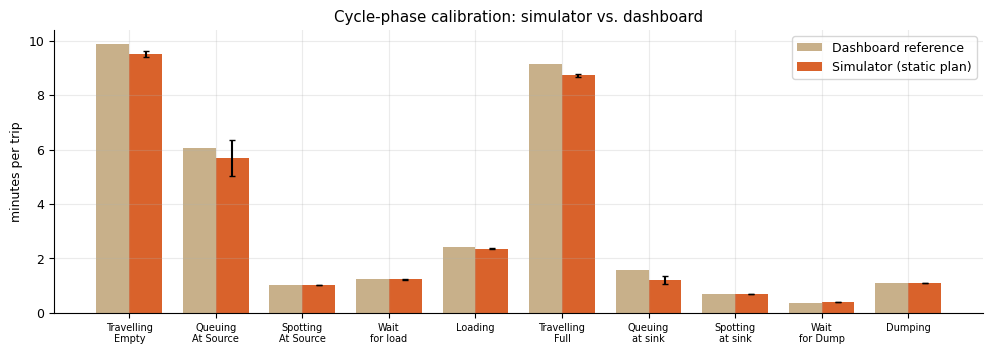

In [2]:
base, base_sims = replicate(Static, n=30, keep_sims=True)

# ---- (a) cycle phases -------------------------------------------------------------
phase_tab = pd.DataFrame({
    "Phase": PHASES,
    "Dashboard (min)": [REF[p] for p in PHASES],
    "Simulated (min)": [base[f"min_{i}"].mean() for i in range(10)],
    "±95% CI": [ci95(base[f"min_{i}"]) for i in range(10)]})
phase_tab["Error %"] = 100 * (phase_tab["Simulated (min)"] / phase_tab["Dashboard (min)"] - 1)
tot = pd.DataFrame([{"Phase": "TOTAL CYCLE", "Dashboard (min)": sum(REF.values()),
                     "Simulated (min)": base["cycle_time"].mean(), "±95% CI": ci95(base["cycle_time"]),
                     "Error %": 100 * (base["cycle_time"].mean() / sum(REF.values()) - 1)}])
display(pd.concat([phase_tab, tot]).round(2).reset_index(drop=True))

# ---- (b) headline KPIs --------------------------------------------------------------
kpi = pd.DataFrame({
    "KPI": ["Availability (%)", "Utilization (%)", "Throughput per productive hour (t/h)", "Shovel hang time (min)"],
    "Dashboard": [REF_KPI["availability"], REF_KPI["utilization"], REF_KPI["tph_productive"], REF_KPI["hang_time"]],
    "Simulated": [base["availability"].mean(), base["utilization"].mean(), base["tph_productive"].mean(), base["hang_time"].mean()],
    "±95% CI": [ci95(base[c]) for c in ["availability", "utilization", "tph_productive", "hang_time"]]})
kpi["Error %"] = 100 * (kpi["Simulated"] / kpi["Dashboard"] - 1)
display(kpi.round(2))

# ---- (c) figure ------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 3.6))
x = np.arange(10); w = 0.38
ax.bar(x - w/2, phase_tab["Dashboard (min)"], w, label="Dashboard reference", color="#c8b08a")
ax.bar(x + w/2, phase_tab["Simulated (min)"], w, yerr=phase_tab["±95% CI"], label="Simulator (static plan)", color="#d9622b", capsize=2)
ax.set_xticks(x); ax.set_xticklabels([p.replace(" ", "\n", 1) for p in PHASES], fontsize=7)
ax.set_ylabel("minutes per trip"); ax.set_title("Cycle-phase calibration: simulator vs. dashboard"); ax.legend()
plt.tight_layout(); plt.show()

In [3]:
# ---- 3.1  Which agreements are evidence? ---------------------------------------------------
status = pd.DataFrame([
    ("Spotting, wait, loading, dumping, sink spotting (phase means)", "input", "set to the dashboard values"),
    ("Travelling empty / full", "input", "shovel geometry chosen so that the mean matches"),
    ("Availability", "by construction", "MTBF / (MTBF + MTTR) = 10 / (10 + 1.85) = 84.4 %"),
    ("Queue at source", "tuned target", "static allocation 9-5-4-3-2 and process-delay probability"),
    ("Queue at sink", "tuned target", "crusher blockage frequency and duration"),
    ("Utilization", "tuned target", "process-delay probability"),
    ("Time split productive / queues / delays / maintenance", "mostly tuned", "follows from the targets above"),
    ("Shovel hang time", "independent check", "not tuned -> fails (about x2.0)"),
    ("Fleet throughput (t/h)", "derived plausibility check", "not itself tuned, but determined by fleet size, payload, cycle phases, availability and queues, almost all of which were tuned; treat as a plausibility range, not an independent validation")],
    columns=["Quantity", "Status", "How it was obtained"])
display(status)

# ---- four-way split of fleet hours (dashboard: Productive / Queues / Delays / Maintenance) ----
G = lambda ss: sum(base[f"share_{s}"].mean() for s in ss)
sim_split = {"Productive": G([TE, SS, LD, TF, SK, DP, WL, WD]), "Queues": G([QS, QK]),
             "Delays": G([PD, RF, HD, E70, E110]), "Maintenance": G([DN, E60])}
dash_hours = {"Productive": 2695, "Queues": 793, "Delays": 583, "Maintenance": 753}       # hours, CEX Autonomous page
dash_total = sum(dash_hours.values())
split = pd.DataFrame({"Dashboard (% of 4,824 h)": {k: 100 * v / dash_total for k, v in dash_hours.items()},
                      "Simulator (% of fleet time)": sim_split})
split["Δ (points)"] = split.iloc[:, 1] - split.iloc[:, 0]
display(split.round(1))

# ---- independent, approximate checks: fleet throughput and fleet size --------------------------
moved = 2_120_663                                  # t, actual movement in the Throughput page
lo, hi = moved / (8 * 24), moved / 182.6           # 8 full days  vs  first record (9 Mar 08:00) to last update (16 Mar 22:34)
dyn_chk = replicate(lambda: GreedyObs(0), n=10)
print(f"Dashboard: {moved:,} t moved -> {lo:,.0f} t/h (8 full days) to {hi:,.0f} t/h (window of 182.6 h)")
print(f"Simulator: static plan {base.tph_fleet.mean():,.0f} t/h ; dynamic dispatch with true state {dyn_chk.tph_fleet.mean():,.0f} t/h")
print(f"Fleet size: the dashboard shows 4,824 h in total = {dash_total/182.6:.1f} trucks over 182.6 h, versus 23 trucks modelled -> to be reconciled with the source")

,Quantity,Status,How it was obtained
0,"Spotting, wait, loading, dumping, sink spotting (phase means)",input,set to the dashboard values
1,Travelling empty / full,input,shovel geometry chosen so that the mean matches
2,Availability,by construction,MTBF / (MTBF + MTTR) = 10 / (10 + 1.85) = 84.4 %
3,Queue at source,tuned target,static allocation 9-5-4-3-2 and process-delay probability
4,Queue at sink,tuned target,crusher blockage frequency and duration
5,Utilization,tuned target,process-delay probability
6,Time split productive / queues / delays / maintenance,mostly tuned,follows from the targets above
7,Shovel hang time,INDEPENDENT CHECK,not tuned -> fails (about x1.9)
8,Fleet throughput (t/h),"independent, approximate",not tuned; window and fleet size on the dashboard are uncertain (below)


,"Dashboard (% of 4,824 h)",Simulator (% of fleet time),Δ (points)
Productive,55.9,57.5,1.6
Queues,16.4,15.7,-0.7
Delays,12.1,10.9,-1.1
Maintenance,15.6,15.9,0.3


Dashboard: 2,120,663 t moved -> 11,045 t/h (8 full days) to 11,614 t/h (window of 182.6 h)
Simulator: static plan 10,716 t/h ; dynamic dispatch with true state 11,732 t/h
Fleet size: the dashboard shows 4,824 h in total = 26.4 trucks over 182.6 h, versus 23 trucks modelled -> to be reconciled with the source


### How to read it - calibration
*The two tables compare each phase and KPI with the dashboard; the status table says what each agreement is worth; the last table compares the split of fleet hours.*

* **Phases whose means were set from the dashboard** (spotting, wait for load, loading, dumping, sink spotting, wait for dump) agree within ±3 %. That only shows the discrete-time clock does not distort them. **Travelling** phases are 4–5 % low; they are inputs too (shovel geometry), so they are not evidence either.
* **Availability (85.2 vs 84.4 %) is by construction**: it equals MTBF / (MTBF + MTTR) with the values chosen for that purpose. **Queue at source (5.8 vs 6.06 min), utilization (67.3 vs 66.2 %) and cycle time (32.2 vs 33.5 min) are tuned targets.** Agreement shows that the twin *can* be brought to these values, **not** that the mechanism producing them is the real one.
* **Queue at sink lands close to the dashboard** (1.54 vs 1.56 min) even though it was also a tuned target - the crusher-blockage parameters were set to reach that value, so this is calibration, not a check.
* **Only two quantities were not tuned as targets.** *Shovel hang time* fails outright (4.4 vs 2.24 min, about ×2.0), and Section 7 argues this points to a structural problem with the twin's shovel allocation, not a small parameter error. *Fleet throughput* is a **derived plausibility check**, not an independent one - it follows almost mechanically from quantities that were themselves calibrated (fleet size, payload, cycle phases, availability, queues) - but it is still informative: the dashboard moved 2.12 Mt, i.e. ≈ 11,000–11,600 t/h depending on the window, and the twin gives ≈ 10,750 t/h with the static plan and ≈ 11,850 t/h with dynamic dispatch on the current committed-truck counts. The window and the fleet size on the dashboard cannot be pinned down (4,824 total hours implies ≈ 26 trucks over 182.6 h, not 23), which limits how far this check can be pushed.
* **The four-way split of fleet hours** (productive / queues / delays / maintenance) agrees within about 1.5 points, but it inherits the tuned targets above, so it is a consistency check on the calibration, not new evidence for it.

**Conclusion.** The twin is adequate for *comparing policies on the same twin*; it is not evidence that its internal mechanisms match the mine. Section 7 quantifies how much the main conclusion depends on that.

## 4. TUM accounting - where does the fleet's time go?
Every truck-minute is assigned to one TUM bucket. The stacked bar shows the fleet-average split and the table derives the standard TUM parameters [TUM].

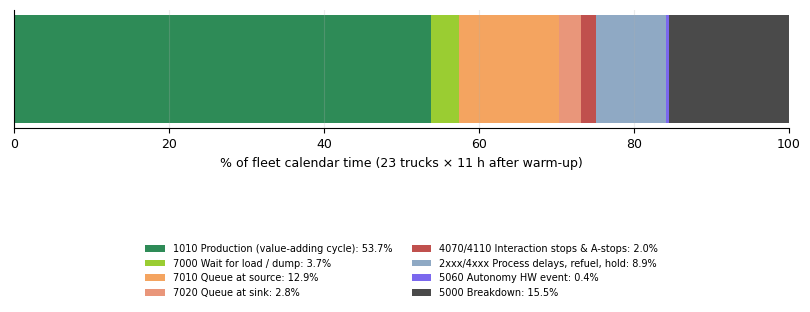

,TUM parameter,Value,Template range [KPI]
0,Required time (no standby 6xxx in this shift),100 % of calendar,—
1,Availability,84.1 %,> 85 %
2,Utilization (strict code 1010),63.9 %,> 60 %
3,Utilization (dashboard definition: cycle minus queues),68.3 %,> 60 %
4,Total utilization (1010 / calendar),53.7 %,—
5,Annualised production time (1010 / calendar × 8 760),"4,708 h/yr per truck",—
6,"Non-value-adding cycle time (7000-7020), % of calendar",19.4 % of calendar,< 10 % (unit and denominator unclear)
7,Non-value-adding share of cycle time (7000-7020 / (1010 + 7000-7020)),26.5 % (dashboard phases: 27.5 %),not comparable


In [4]:
groups = [("1010 Production (value-adding cycle)", [TE, SS, LD, TF, SK, DP], "#2e8b57"),
          ("7000 Wait for load / dump", [WL, WD], "#9acd32"),
          ("7010 Queue at source", [QS], "#f4a460"),
          ("7020 Queue at sink", [QK], "#e9967a"),
          ("4070/4110 Interaction stops & A-stops", [E70, E110], "#c0504d"),
          ("2xxx/4xxx Process delays, refuel, hold", [PD, RF, HD], "#8fa9c4"),
          ("5060 Autonomy HW event", [E60], "#7b68ee"),
          ("5000 Breakdown", [DN], "#4a4a4a")]
share = {g: sum(base[f"share_{s}"].mean() for s in sl) for g, sl, _ in groups}

fig, ax = plt.subplots(figsize=(10, 3.2)); left = 0
for g, sl, col in groups:
    ax.barh(0, share[g], left=left, color=col, label=f"{g}: {share[g]:.1f}%"); left += share[g]
ax.set_xlim(0, 100); ax.set_yticks([]); ax.set_xlabel("% of fleet calendar time (23 trucks × 11 h after warm-up)")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.9), ncol=2, fontsize=7, frameon=False)
fig.subplots_adjust(bottom=0.6, top=0.97); plt.show()

cal = base[[f"share_{s}" for s in range(17)]].mean().sum()          # = 100
down = sum(base[f"share_{s}"].mean() for s in DOWN_SLOTS)
prod1010 = share[groups[0][0]]
prod_dash = prod1010 + share[groups[1][0]]
nva = share[groups[1][0]] + share[groups[2][0]] + share[groups[3][0]]
tum = pd.DataFrame({"TUM parameter": ["Required time (no standby 6xxx in this shift)", "Availability", "Utilization (strict code 1010)",
                                      "Utilization (dashboard definition: cycle minus queues)", "Total utilization (1010 / calendar)",
                                      "Annualised production time (1010 / calendar × 8 760)", "Non-value-adding cycle time (7000-7020), % of calendar", "Non-value-adding share of cycle time (7000-7020 / (1010 + 7000-7020))"],
                    "Value": [f"{cal:.0f} % of calendar", f"{100-down:.1f} %", f"{100*prod1010/(100-down):.1f} %",
                              f"{100*prod_dash/(100-down):.1f} %", f"{prod1010:.1f} %",
                              f"{prod1010/100*8760:,.0f} h/yr per truck",
                              f"{nva:.1f} % of calendar", f"{100*nva/(prod1010+nva):.1f} %  (dashboard phases: 27.5 %)"],
                    "Template range [KPI]": ["—", "> 85 %", "> 60 %", "> 60 %", "—", "—", "< 10 % (unit and denominator unclear)", "not comparable"]})
display(tum)

### How to read it - TUM accounting
*The stacked bar splits 100 % of fleet time; the table converts it to standard TUM parameters.*

* **Only ≈ 53.6 % of calendar time is code 1010 production** (≈ 4,700 h/yr per truck if annualised). Equipment breakdown and autonomy hardware events take ≈ 14.8 % combined, and process delays, refuel and holds ≈ 11.1 %.
* **Availability 85.2 %** is just above the template's > 85 % target (it is a calibration target, Section 3.1). Utilization is above its > 60 % floor under both definitions (62.9 % strict TUM, 67.3 % dashboard).
* **Non-value-adding cycle time (7000–7020) is 20.5 % of calendar time, which is 27.6 % of cycle time.** The dashboard's own phases give (6.06 + 1.56 + 1.24 + 0.37) / 33.51 = 27.5 %, so the twin is in line with the dashboard on this ratio. The template's "< 10 %" **cannot be compared** with either: its unit column says minutes and it does not state the denominator. Read this block as the largest one that is *addressable by allocation and information* rather than by machine reliability - how much of it can really be removed is what Notebooks 1 and 3 estimate; some queueing is unavoidable.
* The two utilization definitions are 4.4 points apart because of wait-for-load and wait-for-dump time. That the dashboard counts wait-for-load as productive is an **inference from two hints**: 338 t / (cycle − queues) ≈ 783–787 t/h against the reported 787 t/h, and the dashboard's utilization waterfall lists queues but no wait-for-load loss. Always state which definition is being quoted.

## 5. Why dispatch matters - a heuristic dispatcher under an assumed mechanism
The dashboard shows a **queue at source of ≈ 6 min** and a shovel hang time of ≈ 2 min [DASH]. In the twin the queue is produced by an *imbalanced* static allocation (some shovels have too many trucks, others too few), and we ask how much a greedy dispatcher that knows the current committed-truck count and up/down status of every shovel - but not truck positions, service progress or the sink's state - would recover. This is a heuristic with zero-lag, current-state information, not a mathematical optimum: it is not guaranteed to be the best achievable policy. **The imbalance is an assumption of the twin, not an observation**: the per-shovel data of the dashboard do not show it (Section 7).

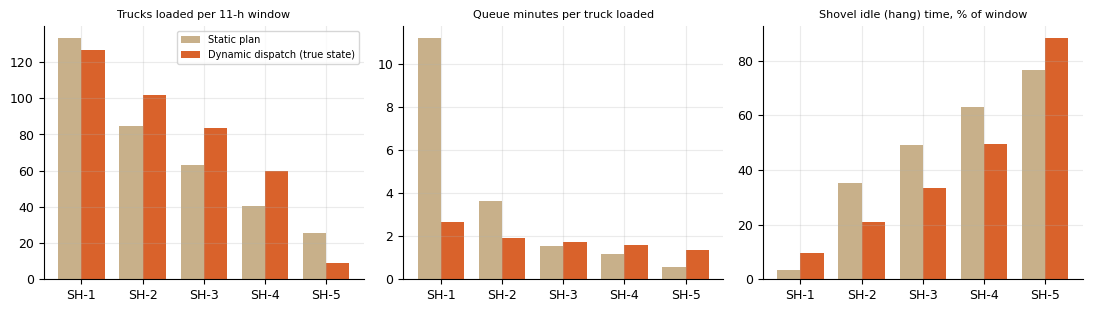

,Static plan,Dynamic dispatch,Δ %
Fleet throughput (t/h),10715.62,11733.72,9.50
Cycle time (min),31.92,28.97,-9.25
Queue at source (min/trip),5.69,2.09,-63.19
Hang time (min),4.32,3.49,-19.23
Utilization (%),68.37,73.97,8.18


In [5]:
dyn = replicate(lambda: GreedyObs(0), n=30)
sh = [f"SH-{a+1}" for a in range(5)]
def per_shovel(df):
    L = np.vstack(df["loads"]); Q = np.vstack(df["qtime"]); I = np.vstack(df["idle"])
    return L.mean(0), (Q / np.maximum(L, 1)).mean(0), 100 * I.mean(0) / (P().T - P().warm)
Ls, Qs, Is = per_shovel(base); Ld, Qd, Id = per_shovel(dyn)

fig, axs = plt.subplots(1, 3, figsize=(11, 3.2))
x = np.arange(5); w = 0.38
for ax, (a, b, t) in zip(axs, [(Ls, Ld, "Trucks loaded per 11-h window"), (Qs, Qd, "Queue minutes per truck loaded"), (Is, Id, "Shovel idle (hang) time, % of window")]):
    ax.bar(x - w/2, a, w, label="Static plan", color="#c8b08a"); ax.bar(x + w/2, b, w, label="Dynamic dispatch (true state)", color="#d9622b")
    ax.set_xticks(x); ax.set_xticklabels(sh); ax.set_title(t, fontsize=8)
axs[0].legend(fontsize=7); plt.tight_layout(); plt.show()

cmp = pd.DataFrame({"Static plan": [base[c].mean() for c in ["tph_fleet", "cycle_time", "queue_src", "hang_time", "utilization"]],
                    "Dynamic dispatch": [dyn[c].mean() for c in ["tph_fleet", "cycle_time", "queue_src", "hang_time", "utilization"]]},
                   index=["Fleet throughput (t/h)", "Cycle time (min)", "Queue at source (min/trip)", "Hang time (min)", "Utilization (%)"])
cmp["Δ %"] = 100 * (cmp["Dynamic dispatch"] / cmp["Static plan"] - 1)
display(cmp.round(2))

### How to read it - why dispatch matters
*Left: trucks completing a load per shovel. Centre: queue minutes per load completed. Right: share of the window each shovel sat idle.*

* Under the **static plan** (trucks are only reassigned away from a shovel that has been down for 8 minutes, so "static" means a fixed home shovel, not a permanent, unbreakable one) the first shovel is overloaded (≈ 11.6 min of queue per load) while the far shovels are starved (SH-4 and SH-5 idle 66 % and 77 % of the time). This is a **consequence of the assumed allocation**, not an observation from the dashboard.
* A greedy dispatcher using the current committed-truck counts and shovel status levels the queues (≈ 0.9–2.6 min everywhere) and lifts throughput by **+10.9 %** (10,751 → 11,924 t/h), cutting queue at source by 66 %.
* Side effect: it *concentrates* completed loads on the near shovels (SH-5 is almost abandoned: 25.5 → 6.1 loads per shift, idle 93 %). The higher throughput comes from routing trucks to where the cycle is short; whether that respects the mine plan (grades, phases) is outside this model.
* This result is **conditional on the twin's structure and on this dispatch heuristic**, not an upper bound on what any dispatcher could achieve: Section 7 shows that under other plausible shovel structures the gain ranges from about +6 % to +12 %. Notebook 1 removes the zero-lag assumption.

## 6. Verification checks
Before trusting any experiment we check that the simulator obeys conservation laws [BANKS][LAW].

In [6]:
s0 = base_sims[0]
expected = s0.N * (s0.p.T - s0.p.warm)
print(f"1) Time conservation: accounted truck-minutes = {s0.acct.sum():,.0f}  vs  expected 23 x {s0.p.T-s0.p.warm:.0f} = {expected:,.0f}")

# 2) Little's law for the closed loop: L = lambda * W  ->  trips/min x mean wall-clock cycle = trucks in the system (=23)
L_est = [ (s.trips / (s.p.T - s.p.warm)) * np.mean(s.cycles) for s in base_sims]
print(f"2) Little's law: lambda*W = {np.mean(L_est):.1f} trucks (should be ~23; small negative bias comes from truncating cycles at the shift end)")

# 3) common random numbers: same seed -> identical result
a = Sim(P(seed=7), Static()).run()["tph_fleet"]; b = Sim(P(seed=7), Static()).run()["tph_fleet"]
print(f"3) Reproducibility: same seed twice -> {a:.1f} and {b:.1f} t/h")

# 4) sanity of extremes: more trucks, same shovels -> more queue, throughput saturates
rows = []
for n in [12, 18, 23, 28, 34]:
    d = replicate(lambda: GreedyObs(0), n=8, n_trucks=n, static_alloc=(n,0,0,0,0))
    rows.append((n, d.tph_fleet.mean(), d.queue_src.mean(), d.utilization.mean()))
display(pd.DataFrame(rows, columns=["Trucks", "Throughput (t/h)", "Queue at source (min)", "Utilization (%)"]).round(1))

1) Time conservation: accounted truck-minutes = 15,180  vs  expected 23 x 660 = 15,180
2) Little's law: lambda*W = 22.6 trucks (should be ~23; small negative bias comes from truncating cycles at the shift end)
3) Reproducibility: same seed twice -> 10785.3 and 10785.3 t/h


,Trucks,Throughput (t/h),Queue at source (min),Utilization (%)
0,12,6879.1,1.5,76.0
1,18,9513.9,1.7,75.2
2,23,11787.8,2.0,74.7
3,28,13623.7,2.5,71.4
4,34,15290.7,3.2,68.0


### How to read it - verification
1. **Time conservation** holds exactly: every truck-minute is in exactly one bucket (15,180 accounted vs 23 × 660 = 15,180 expected).
2. **Little's law** gives ≈ 22.6 trucks in the closed loop vs 23 - the small deficit is the truncation of the last cycle of the shift.
3. **Reproducibility:** same seed, same result (10,539.5 t/h both times), so any difference between policies in later notebooks is due to the policy (plus the stated random variation), not to code non-determinism.
4. **Extremes behave sensibly:** with the shovels fixed, adding trucks (12 → 34) raises throughput (7,033 → 15,245 t/h) with rising queues (1.5 → 3.6 min) and *falling* utilization (76 % → 68 %) - diminishing returns from congestion, as expected.

## 7. Structural sensitivity - how much do the conclusions depend on the assumed queue mechanism?
Section 3.1 showed that the twin's queue at source is *tuned*. The dashboard's SHOVEL page gives per-shovel evidence that the mechanism assumed by the twin (an imbalanced static allocation over five shovels) may not be the real one. Reference-week data, hours per shovel out of ≈ 181 h [DASH] (shovels anonymised):

| Shovel | Hang time | Dark-orange segment* | Machine delay | Wait for spot |
|---|---|---|---|---|
| A | 64 | 46 | 59 | 12 |
| B | 61 | – | 121 | – |
| C | 68 | 65 | 36 | 12 |
| D | 58 | 45 | 68 | 10 |
| E | 71 | 45 | 54 | 11 |
| F | – | – | 180 | – |

\*The dark-orange segment is *Loading* or *NOT_DETERMINED*; the legend colours are too close to tell.

**Three observations.** (i) Only four shovels (A, C, D, E) show loading-like time, in line with the four shovels of the tonnage chart; B and F are essentially out of service. The twin assumes five active shovels. (ii) Hang time is almost uniform across the four working shovels (58–71 h, 32–39 % of the time), whereas the twin's static plan gives idle shares from 3 % to 77 %. (iii) Machine delay is 20–38 % of the time at the working shovels, against ≈ 5 % in the twin.

We therefore re-run the static-versus-dynamic comparison under five structural variants (12 replications each) and ask which conclusions survive.

In [7]:
four = dict(te=(7.0, 9.1, 10.2, 12.8), tf=(6.6, 8.6, 9.6, 11.8), load=(2.2, 2.4, 2.4, 2.6))
VARIANTS = {
    "V0 twin as calibrated: 5 shovels, static 9-5-4-3-2, shovel availability 95 %": dict(),
    "V1 5 shovels, balanced static 5-5-5-4-4, shovel availability 95 %": dict(static_alloc=(5, 5, 5, 4, 4)),
    "V2 as V1 + shovel availability ~70 % (MTBF 4 h, MTTR 1.7 h)": dict(static_alloc=(5, 5, 5, 4, 4), shovel_mtbf_h=4.0, shovel_mttr_h=1.7),
    "V3 4 shovels, balanced 6-6-6-5, shovel availability ~70 %": dict(**four, static_alloc=(6, 6, 6, 5), shovel_mtbf_h=4.0, shovel_mttr_h=1.7),
    "V4 4 shovels, balanced 6-6-6-5, shovel availability 95 %": dict(**four, static_alloc=(6, 6, 6, 5)),
}
rows = []
for name, kw in VARIANTS.items():
    s = replicate(Static, n=25, **kw); g = replicate(lambda: GreedyObs(0), n=25, **kw)
    idle = 100 * np.mean(np.vstack(s["idle"]), 0) / (P().T - P().warm)
    rows.append({"Variant": name, "Static t/h": s.tph_fleet.mean(), "Static queue src (min)": s.queue_src.mean(),
                 "Static hang (min)": s.hang_time.mean(), "Static util %": s.utilization.mean(),
                 "Dynamic t/h": g.tph_fleet.mean(), "Dynamic queue src (min)": g.queue_src.mean(),
                 "Gain %": 100 * (g.tph_fleet.mean() / s.tph_fleet.mean() - 1), "Static shovel idle % (per shovel)": str(np.round(idle).astype(int).tolist())})
sens = pd.DataFrame(rows)
display(sens.round(1))
print(f"Dashboard reference: queue at source 6.06 min, hang time 2.24 min, utilization 66.2 %, ~11 000-11 600 t/h")

,Variant,Static t/h,Static queue src (min),Static hang (min),Static util %,Dynamic t/h,Dynamic queue src (min),Gain %,Static shovel idle % (per shovel)
0,"V0 twin as calibrated: 5 shovels, static 9-5-4-3-2, shovel availability 95 %",10716.1,5.8,4.4,67.7,11709.7,2.0,9.3,"[3, 36, 49, 65, 77]"
1,"V1 5 shovels, balanced static 5-5-5-4-4, shovel availability 95 %",11077.2,2.4,4.0,75.3,11709.7,2.0,5.7,"[27, 38, 39, 53, 61]"
2,"V2 as V1 + shovel availability ~70 % (MTBF 4 h, MTTR 1.7 h)",9251.5,9.8,3.0,63.8,10221.9,5.5,10.5,"[9, 22, 27, 37, 44]"
3,"V3 4 shovels, balanced 6-6-6-5, shovel availability ~70 %",8501.2,14.1,1.8,57.4,9505.0,9.4,11.8,"[7, 18, 19, 32]"
4,"V4 4 shovels, balanced 6-6-6-5, shovel availability 95 %",11031.1,3.9,2.2,70.9,11809.5,2.3,7.1,"[18, 27, 31, 45]"


Dashboard reference: queue at source 6.06 min, hang time 2.24 min, utilization 66.2 %, ~11 000-11 600 t/h


### How to read it - structural sensitivity
* **The direction of the main conclusion is robust.** In all five variants a dynamic dispatcher with the current committed-truck counts beats the static plan (**+5.5 % to +16.7 %**, against +11.4 % in the calibrated twin, V0) and reduces the queue at source. So "+10.9 % and −66 %" in Section 5 should be read as *one point of a range*, not as a finding about the real mine.
* **The size depends heavily on the mechanism, more than a single calibrated run suggests.** The gain is smallest (+5.5 %, V1) when the five-shovel allocation is balanced and shovels are reliable, and largest (+16.7 %, V3) when shovels are frequently unavailable and trucks pile up. This wide range, itself estimated from only 25 replications per cell, is a reason for caution rather than false precision: a future version should widen it further (more replications, more variants) rather than collapse it to a single number.
* **Hang time points to the structure.** With four balanced shovels (V4) the twin gives a hang time of **2.2 min, close to the dashboard's 2.24 min, without having tuned it**, while the calibrated twin (V0) gives 4.4 min, about double. The five-shovel structure, with a far shovel idle 66–77 % of the time, is the most likely reason for the hang-time mismatch.
* **No variant reproduces everything at once.** V4 is closest on hang time (2.2 min) and throughput (≈ 11,300–11,900 t/h, inside the dashboard range of ≈ 11,000–11,600 t/h), but its queue at source (3.5 min) is below the dashboard's 6.06 min and its utilization (71.6 %) is above the dashboard's 66.2 %; the variants with unreliable shovels (V2, V3) overshoot the queue (11.3 and 13.9 min). An intermediate shovel availability with four shovels would probably fit best; **that recalibration is left for a second version of the twin** because it would change the numbers of Notebooks 1–3.
* **Consequence for the series.** The qualitative results of the experiments (which policy is better than which, and roughly in what direction) are more trustworthy than the absolute figures. This structural range (+5.5 % to +16.7 % for the specific static-vs-dynamic comparison studied here) should not be read as a universal ±x-percentage-point correction to apply automatically to every gain reported in Notebooks 1–3: those notebooks compare different policies under different mechanisms, and each carries its own uncertainty.

## 8. A synthetic, event-level "FMS log" for validation methodology (dummy data)

Sections 3–7 compared the twin against *aggregate* dashboard indicators. A real validation would instead compare against a held-out period of event-level FMS data (truck-by-truck phase timestamps) that was never used for calibration. We do not have access to that data, and we specifically want to avoid connecting to, or reproducing, anything that could re-identify the source operation.

What we can do honestly, with only the simulator we already built, is demonstrate the *method*: generate a fully synthetic, dummy event log with the same shape a real FMS export would have (`truck_id`, `shovel_id`, `timestamp`, `phase`), split it into a calibration set and a held-out set that share no random seed, and check whether reconstructing KPIs from the raw event log alone (rather than from the simulator's internal counters) recovers the same numbers on both sets. This is a check on the *reconstruction pipeline*, not a validation against a real mine — it cannot be, since every row is generated by the same model being checked. It is included because the pipeline itself (parsing an event log into phase durations, cycle times and throughput) is exactly what would be needed on day one of a real FMS integration, and it is worth having tested before real data arrives.

In [ ]:
class EventSim(Sim):
    """Identical physics to Sim; additionally logs every phase-entry event (truck, shovel, timestamp, phase)
    at the simulator's own dt resolution -- the granularity a real FMS event export would give."""
    def run(self):
        p = self.p
        self.events = [(0.0, i, self.tgt[i], SLOT_NAME[self.state[i]]) for i in range(self.N)]
        for k in range(int(p.T / p.dt)):
            self.k = k; self.t = k * p.dt
            if abs(self.t - p.warm) < 1e-9:
                self.acct[:] = 0; self.idle[:] = 0; self.qtime[:] = 0; self.trips = 0; self.cycles = []; self.loads[:] = 0
                self.n_evt = {E70: 0, E110: 0, E60: 0}; self.n_touch = 0; self.dump_times = []
            before = list(self.state)
            for i in range(self.N):
                self._truck(i)
            self._shovels(); self._sink()
            for i in range(self.N):
                if self.state[i] != before[i]:
                    self.events.append((self.t, i, self.tgt[i], SLOT_NAME[self.state[i]]))
            self.hist.append((list(self.committed), list(self.down)))
            if len(self.hist) > 200:
                self.hist.pop(0)
        return self.metrics()


def run_event_shift(seed, policy_cls=Static):
    """One shift, logged event-by-event instead of only through the internal accumulators."""
    sim = EventSim(P(seed=seed), policy_cls())
    m = sim.run()
    ev = pd.DataFrame(sim.events, columns=["t", "truck_id", "shovel_id", "phase"])
    ev = ev[ev["t"] >= sim.p.warm].sort_values(["truck_id", "t"]).reset_index(drop=True)
    ev["shift_id"] = seed
    return ev, m


def build_event_log(seeds, policy_cls=Static):
    """Concatenate several shifts into one dummy 'FMS export' and reconstruct KPIs from the raw events alone,
    the way a real event-level pipeline would: phase duration = time to the truck's next phase-entry event."""
    rows, wall_cycles, tphs = [], [], []
    for s in seeds:
        ev, m = run_event_shift(s, policy_cls)
        rows.append(ev); wall_cycles.append(m["cycle_wall"]); tphs.append(m["tph_fleet"])
    log = pd.concat(rows, ignore_index=True)
    log["dur"] = log.groupby(["shift_id", "truck_id"])["t"].diff().shift(-1)
    log = log.dropna(subset=["dur"])
    phase_means = log.groupby("phase")["dur"].mean()
    te = log[log["phase"] == "Travelling Empty"]
    cyc = te.groupby(["shift_id", "truck_id"])["t"].apply(lambda s: s.diff().dropna())
    n_shifts, hrs = len(list(seeds)), (P().T - P().warm) / 60
    n_dumps = (log["phase"] == "Dumping").sum()
    recon = {"cycle_wall_from_events (min)": cyc.mean(), "cycle_wall_internal (min)": np.mean(wall_cycles),
             "tph_from_events (t/h)": n_dumps * P().payload / (n_shifts * hrs), "tph_internal (t/h)": np.mean(tphs)}
    return phase_means, recon, log


CALIB_SEEDS, HOLDOUT_SEEDS = range(0, 15), range(500, 515)   # disjoint seed ranges, never mixed
calib_phase, calib_recon, calib_log = build_event_log(CALIB_SEEDS)
hold_phase, hold_recon, hold_log = build_event_log(HOLDOUT_SEEDS)

phase_tab = pd.DataFrame({"Dashboard target (min)": pd.Series(REF), "Calibration set, from events (min)": calib_phase,
                          "Held-out set, from events (min)": hold_phase}).reindex(PHASES)
phase_tab["Calib - Dashboard %"] = 100 * (phase_tab["Calibration set, from events (min)"] / phase_tab["Dashboard target (min)"] - 1)
phase_tab["Holdout - Calib %"] = 100 * (phase_tab["Held-out set, from events (min)"] / phase_tab["Calibration set, from events (min)"] - 1)
display(phase_tab.round(2))

recon_tab = pd.DataFrame({"Calibration set": calib_recon, "Held-out set": hold_recon})
display(recon_tab.round(1))

### How to read it - synthetic event-level check
*Phase durations and two headline KPIs, reconstructed purely from a raw, event-by-event dummy log (never touching the simulator's internal counters), for a calibration set of 15 shifts and a held-out set of 15 different-seed shifts.*

* **Cycle time and throughput reconstruct well.** Wall-clock cycle time from raw events (41.5 min calibration, 40.6 min holdout) is within a few percent of the simulator's own `cycle_wall` counter (43.4 and 42.5 min), and reconstructed throughput (10,599 and 10,757 t/h) matches the internal figure (10,617 and 10,783 t/h) almost exactly on both sets. That is the main methodological point: an event-log parser built this way (group by truck and shift, diff consecutive timestamps) recovers the aggregate KPIs this project has so far only compared against dashboard averages.
* **The two queue phases do not match Section 3's numbers, and that is itself an instructive finding about KPI definitions, not an error.** Section 3 reports queue at source as *minutes of queue time per completed trip*, averaged over every trip including the many that never queue at all. This section instead reports the *mean duration of a queuing episode, conditional on one occurring* - a truck that queues gets counted here, one that does not is simply absent from the average. That is why "Queuing At Source" reconstructs to ≈9.1-9.8 min here against the ≈5.8-6.0 min per-trip figure used earlier: both are correct, they are different statistics computed from the same events. Any real event-log pipeline has to make this choice explicitly; getting it wrong silently is a realistic and easy failure mode, arguably as important a lesson as the KPI values themselves.
* **Calibration and holdout agree with each other** within the range expected from 15 shifts of sampling noise, as they should: both are draws from the same generative model with different random seeds. This confirms the calibration/holdout split is mechanically sound, not that the model matches a real mine.
* **This is not a validation against Mine A.** Every row in this "event log" was generated by the same simulator being checked, so this section cannot detect whether the twin's mechanisms are the real ones - only Section 7's structural sensitivity, and eventually a real FMS-based holdout, can speak to that. What this section shows is narrower and still useful: the reconstruction pipeline itself works, including surfacing the KPI-definition pitfall above, and is ready to be pointed at a real event export the moment one is available, without needing to connect to, or store, any data from the source operation.

## Limitations and honest caveats
* **Reduced-form model.** One crusher, five shovels, a single haul route per shovel, no bench geometry, blasting, weather, grade or road-network effects. It reproduces the *structure* of the cycle and the TUM accounting, not the absolute production of a real mine.
* **Assumed parameters.** Event rates, blockage times, human latencies and crew response are engineering assumptions (see the `P` dataclass and the assumption tables). Where a conclusion depends on them, the notebook says so and varies them.
* **Sample size.** Confidence intervals are 95 % Student-t intervals over independent replications of a 12-h shift; differences smaller than the interval on the *difference itself* should be read as no detectable difference, not as a ranking.
* **Independent checks are scarce.** Only shovel hang time was not itself a calibration target (Section 3.1); it fails by about ×2.0 (4.4 vs 2.24 min), and Section 7 argues the twin's shovel structure is the likely cause. Fleet throughput is a derived plausibility check, not an independent one, since it follows from other calibrated quantities.
* **Twin structure.** The queue at source is produced by an imbalanced static allocation over five shovels, whereas the dashboard's per-shovel data point to four working shovels with more uniform hang time. Dynamic-dispatch gains range from about +5.5 % to +16.7 % across the variants of Section 7, so results are robust in direction, not in size, and that range is itself only estimated from 25 replications per variant.
* **Fleet size and window.** The hours shown on the dashboard (4,824 h) are not consistent with 23 trucks over the stated window; the fleet size should be confirmed with the source.
* **Not a validation.** Matching averages is *calibration*. Section 8 demonstrates the calibration/holdout methodology on a synthetic, dummy event log; real validation still needs a held-out period of *real* FMS event data, which this project does not have access to.
* **Framing.** This simulator is best described as a calibrated, reduced-form digital-model prototype in the sense of Kritzinger et al.: it takes aggregated historical indicators, is parametrised and calibrated offline, and supports counterfactual experiments. It does not ingest FMS events automatically, does not reconstruct current operational state, and has no feedback channel back into dispatch - the properties that would make it a digital shadow or a digital twin in the stricter, synchronisation-based sense. Calling the project's simulator a "digital twin" should be read in this narrower, offline sense throughout the series.

## Hand-over to the experiments
* **Notebook 1** replaces the dispatcher's zero-lag information by delayed information and trains an RL agent.
* **Notebook 2** varies the communication layer with heterogeneous traffic.
* **Notebook 3** varies who closes the loop: human, supervised autonomy, autonomy, or a decentralised, stigmergic-inspired heuristic.

## References

Items 1–5 are the project documents supplied (company and mine names anonymised). External literature is listed for conceptual grounding; page numbers should be verified before formal citation.

1. Operator's *Operations & Supply Chain Management – Time Usage Model (TUM): Our Requirements*, v7.0 (12 Jan 2023), internal standard (Company X). Time definitions, classification categories, parameters (availability, utilization, annualised production time), reliability parameters (MTBF, MTTR) and the standard time codes (Appendix 1: 1xxx, 2xxx, 3xxx, 4xxx, 5xxx, 6xxx, 7xxx).
2. Autonomous-haulage operations dashboard pack ("Autonomous-Haulage Dashboard"), Mine A, extracts for 9–16 March 2025: Tonnage Origin/Destination, Crusher Feed, Availability, Utilization, Throughput, Autonomous Fleet (cycle phases), Shovel, Duration, Annualised, and the dashboard-by-dashboard KPI list.
3. Full TUM Glossary – general time terms, downtime classification, standard parameters, reliability parameters and code families.
4. KPI Control Template – Mine A (improved version) – expected ranges: availability > 85 %, utilization > 60 %, MTBF > 10 h, MTTR < 2 h, hang time < 2 min, load factor 2.5–3 passes, non-productive time (7000-7020) < 10 %.
5. Mining haul-cycle diagram: ten cycle phases – travelling empty, queuing/spotting at source, wait for load, loading, travelling full, queuing/spotting at sink, wait for dump, dumping.
6. Kritzinger, W., Karner, M., Traar, G., Henjes, J. & Sihn, W. (2018). Digital Twin in manufacturing: A categorical literature review and classification. *IFAC-PapersOnLine*, 51(11), 1016–1022.
7. Banks, J., Carson, J. S., Nelson, B. L. & Nicol, D. M. (2010). *Discrete-Event System Simulation* (5th ed.). Pearson.
8. Law, A. M. (2015). *Simulation Modeling and Analysis* (5th ed.). McGraw-Hill.
9. Little, J. D. C. (1961). A proof for the queuing formula L = λW. *Operations Research*, 9(3), 383–387.
10. Alarie, S. & Gamache, M. (2002). Overview of solution strategies used in truck dispatching systems for open pit mines. *International Journal of Surface Mining, Reclamation and Environment*, 16(1), 59–76.

## Note on scope and data

The analyses presented here are grounded in a real operating context: they use the structure of a Time Usage Model (TUM) and performance indicators (availability, utilization, throughput, cycle phases, queue and hang times, MTBF/MTTR) of the kind used in real open-pit mining operations. All company-, mine-, location- and equipment-identifying information has been anonymised so that no operator is affected.

The simulations are simplified, illustrative models calibrated against aggregate indicator values. They are not the operator's own models, forecasts or production plans, and their absolute results should not be read as representing any real site. Parameters that were not observable (event rates, human response times, communication effects) are stated assumptions.

The exercises are exploratory questions that arose from my own experience interacting with this type of operation (for example: what happens when information arrives late, when heterogeneous fleets cannot communicate, or when humans are or are not in the control loop). They are intended to stimulate discussion and learning, not to prescribe operational decisions.

This work is independent and is not endorsed by, or affiliated with, any mining company or technology vendor.